In [16]:
import os
os.environ['TF_ENABLE_ONEDNN_OPTS']= '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import keras as kr
from keras.callbacks import EarlyStopping



In [17]:
set_date_antrenare = kr.utils.image_dataset_from_directory(
    'D:/Licenta/DataSetOrganized/data/train',
    labels="inferred",
    label_mode="int",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(256, 256),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    format="tf",
    verbose=True,
)

set_date_validare = kr.utils.image_dataset_from_directory(
    'D:/Licenta/DataSetOrganized/data/validation',
    labels="inferred",
    label_mode="int",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(256, 256),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    format="tf",
    verbose=True,
)


Found 3000 files belonging to 5 classes.
Found 600 files belonging to 5 classes.


In [18]:
model_data_augumentation = kr.Sequential([kr.layers.RandomFlip("horizontal_and_vertical"),kr.layers.RandomZoom(0.2),kr.layers.RandomRotation(0.2),kr.layers.RandomBrightness(0.1),kr.layers.RandomContrast(0.1)])

In [19]:
model_antrenare = kr.models.Sequential()

model_antrenare.add(kr.layers.Input(shape=(256,256,3)))
model_antrenare.add(model_data_augumentation)
model_antrenare.add(kr.layers.Rescaling(1./255))

model_antrenare.add(kr.layers.Conv2D(filters=64, kernel_size= 3, padding='same',kernel_initializer='he_normal'))
model_antrenare.add(kr.layers.BatchNormalization())
model_antrenare.add(kr.layers.Activation('relu'))
model_antrenare.add(kr.layers.MaxPooling2D(pool_size=2,strides=2))

model_antrenare.add(kr.layers.Conv2D(filters=128, kernel_size= 3, padding='same',kernel_initializer='he_normal'))
model_antrenare.add(kr.layers.BatchNormalization())
model_antrenare.add(kr.layers.Activation('relu'))
model_antrenare.add(kr.layers.MaxPooling2D(pool_size=2,strides=2))

model_antrenare.add(kr.layers.Conv2D(filters=256, kernel_size= 3, padding='same',kernel_initializer='he_normal'))
model_antrenare.add(kr.layers.BatchNormalization())
model_antrenare.add(kr.layers.Activation('relu'))
model_antrenare.add(kr.layers.MaxPooling2D(pool_size=2,strides=2))

model_antrenare.add(kr.layers.GlobalAveragePooling2D())

model_antrenare.add(kr.layers.Dense(256, activation='relu'))
model_antrenare.add(kr.layers.Dropout(0.4))
model_antrenare.add(kr.layers.Dense(5, activation='softmax'))

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False)
optimizer_fn = tf.keras.optimizers.AdamW(learning_rate=0.0005,weight_decay=1e-4)

model_antrenare.compile(optimizer=optimizer_fn, loss=loss_fn,metrics=['accuracy'])

reduce_lr = kr.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,patience=10,min_lr=1e-6,verbose=1)

early_stop = kr.callbacks.EarlyStopping(monitor='val_loss', patience=20, verbose=1,restore_best_weights=True,start_from_epoch=5)

model_antrenare.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 256, 256, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256, 256, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 256, 256, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128, 128, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 128, 128, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64, 64, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 64, 64, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 439,685 (1.68 MB)

 Trainable params: 438,789 (1.67 MB)

 Non-trainable params: 896 (3.50 KB)

In [20]:
model_antrenare_istoric = model_antrenare.fit(x=set_date_antrenare,validation_data = set_date_validare,epochs=60,callbacks=[early_stop,reduce_lr])

Epoch 1/60
94/94 ━━━━━━━━━━━━━━━━━━━━ 282s 3s/step - accuracy: 0.5663 - loss: 1.0766 - val_accuracy: 0.2567 - val_loss: 1.9473 - learning_rate: 5.0000e-04
Epoch 2/60
94/94 ━━━━━━━━━━━━━━━━━━━━ 279s 3s/step - accuracy: 0.6310 - loss: 0.9194 - val_accuracy: 0.3050 - val_loss: 1.8709 - learning_rate: 5.0000e-04
Epoch 3/60
94/94 ━━━━━━━━━━━━━━━━━━━━ 280s 3s/step - accuracy: 0.6410 - loss: 0.8787 - val_accuracy: 0.4117 - val_loss: 1.3410 - learning_rate: 5.0000e-04
Epoch 4/60
94/94 ━━━━━━━━━━━━━━━━━━━━ 283s 3s/step - accuracy: 0.6557 - loss: 0.8340 - val_accuracy: 0.5950 - val_loss: 0.9753 - learning_rate: 5.0000e-04
Epoch 5/60
94/94 ━━━━━━━━━━━━━━━━━━━━ 284s 3s/step - accuracy: 0.6763 - loss: 0.8111 - val_accuracy: 0.5950 - val_loss: 0.9678 - learning_rate: 5.0000e-04
Epoch 6/60
94/94 ━━━━━━━━━━━━━━━━━━━━ 262s 3s/step - accuracy: 0.6963 - loss: 0.7690 - val_accuracy: 0.5633 - val_loss: 1.2341 - learning_rate: 5.0000e-04
Epoch 7/60
94/94 ━━━━━━━━━━━━━━━━━━━━ 262s 3s/step - accuracy: 0.7003 

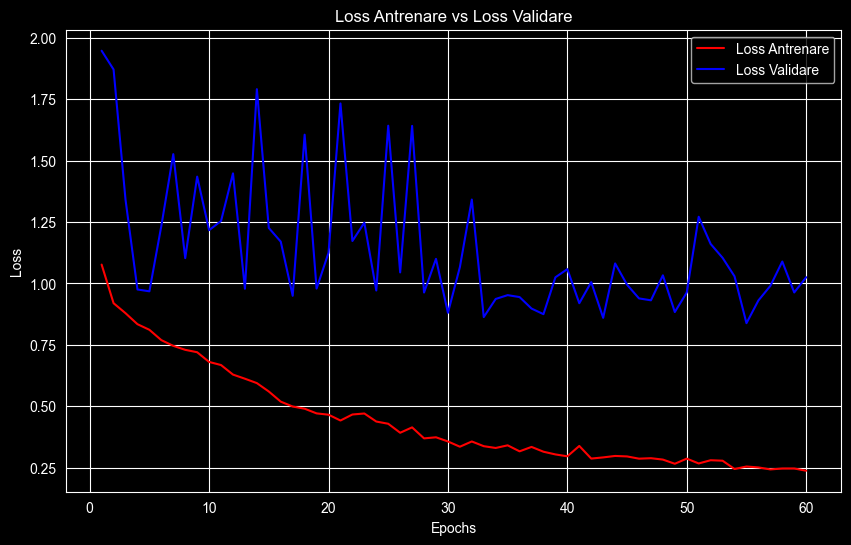

In [21]:
loss = model_antrenare_istoric.history['loss']
val_loss = model_antrenare_istoric.history['val_loss']
epochs = range(1, len(loss) + 1)


plt.figure(figsize = (10,6))
plt.plot(epochs, loss, 'r', label='Loss Antrenare')
plt.plot(epochs, val_loss, 'b', label='Loss Validare')
plt.title('Loss Antrenare vs Loss Validare')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

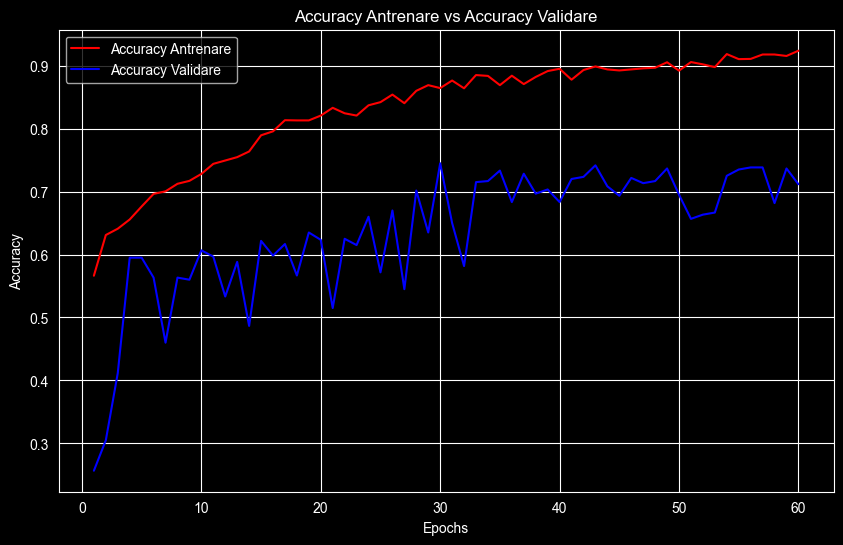

In [22]:
accuracy = model_antrenare_istoric.history['accuracy']
val_accuracy = model_antrenare_istoric.history['val_accuracy']
epochs = range(1, len(accuracy) + 1)


plt.figure(figsize = (10,6))
plt.plot(epochs, accuracy, 'r', label='Accuracy Antrenare')
plt.plot(epochs, val_accuracy, 'b', label='Accuracy Validare')
plt.title('Accuracy Antrenare vs Accuracy Validare')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()